Démarrage du pipeline de prétraitement (Étape 2)...
✅ Image brute CREMMA chargée.
✅ Filtre CLAHE appliqué.
✅ Binarisation adaptative (Sauvola) appliquée.


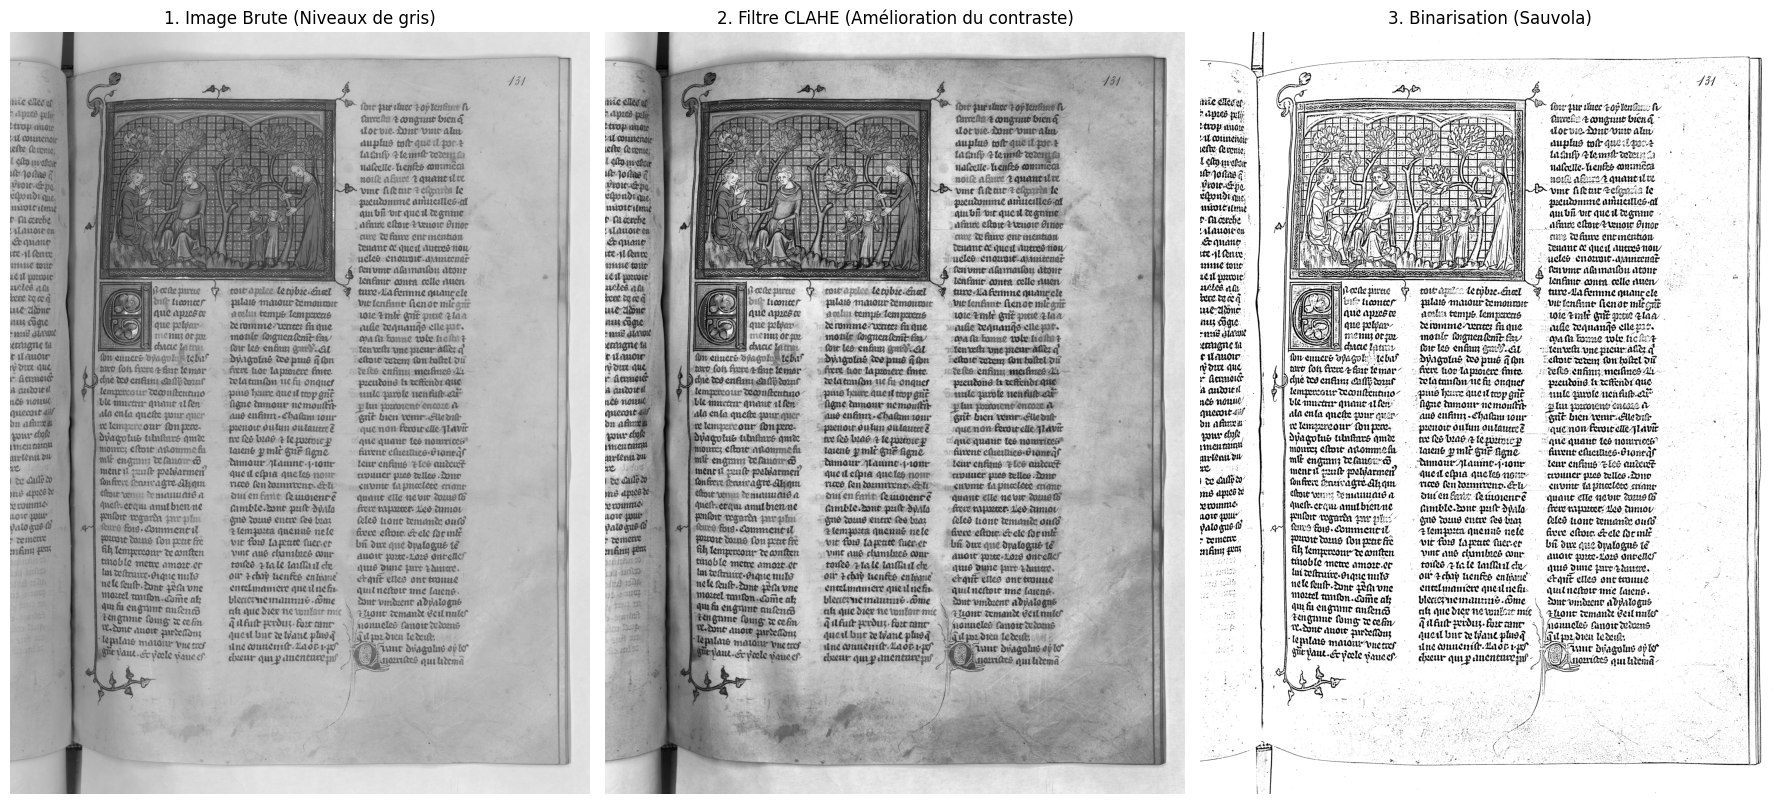

In [2]:
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np
from skimage.filters import threshold_sauvola

# 1. Chemins
chemin_image_brute = "../dataset_nlp/raw_pages/page_cremma.jpg"
dossier_sortie = "../dataset_nlp/processed_pages"
os.makedirs(dossier_sortie, exist_ok=True)

print("Démarrage du pipeline de prétraitement (Étape 2)...")

# 2. Chargement en niveaux de gris
image = cv2.imread(chemin_image_brute, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("❌ Erreur : Image introuvable. Vérifie le nom et le dossier.")
else:
    print("✅ Image brute CREMMA chargée.")

    # 3. Filtre CLAHE (Contraste)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    image_clahe = clahe.apply(image)
    print("✅ Filtre CLAHE appliqué.")
    
    # 4. Binarisation de Sauvola (Exigence stricte du brief)
    # Sauvola est calculé avec une "fenêtre" glissante pour s'adapter à l'éclairage local
    window_size = 25
    thresh_sauvola = threshold_sauvola(image_clahe, window_size=window_size)
    
    # Création de l'image binaire (texte en noir, fond en blanc)
    image_binaire = (image_clahe > thresh_sauvola).astype(np.uint8) * 255
    print("✅ Binarisation adaptative (Sauvola) appliquée.")
    
    # 5. Sauvegarde
    cv2.imwrite(f"{dossier_sortie}/page_clahe.jpg", image_clahe)
    cv2.imwrite(f"{dossier_sortie}/page_binaire.jpg", image_binaire)

    # 6. Affichage professionnel
    fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('1. Image Brute (Niveaux de gris)')
    axes[0].axis('off')
    
    axes[1].imshow(image_clahe, cmap='gray')
    axes[1].set_title('2. Filtre CLAHE (Amélioration du contraste)')
    axes[1].axis('off')
    
    axes[2].imshow(image_binaire, cmap='gray')
    axes[2].set_title('3. Binarisation (Sauvola)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

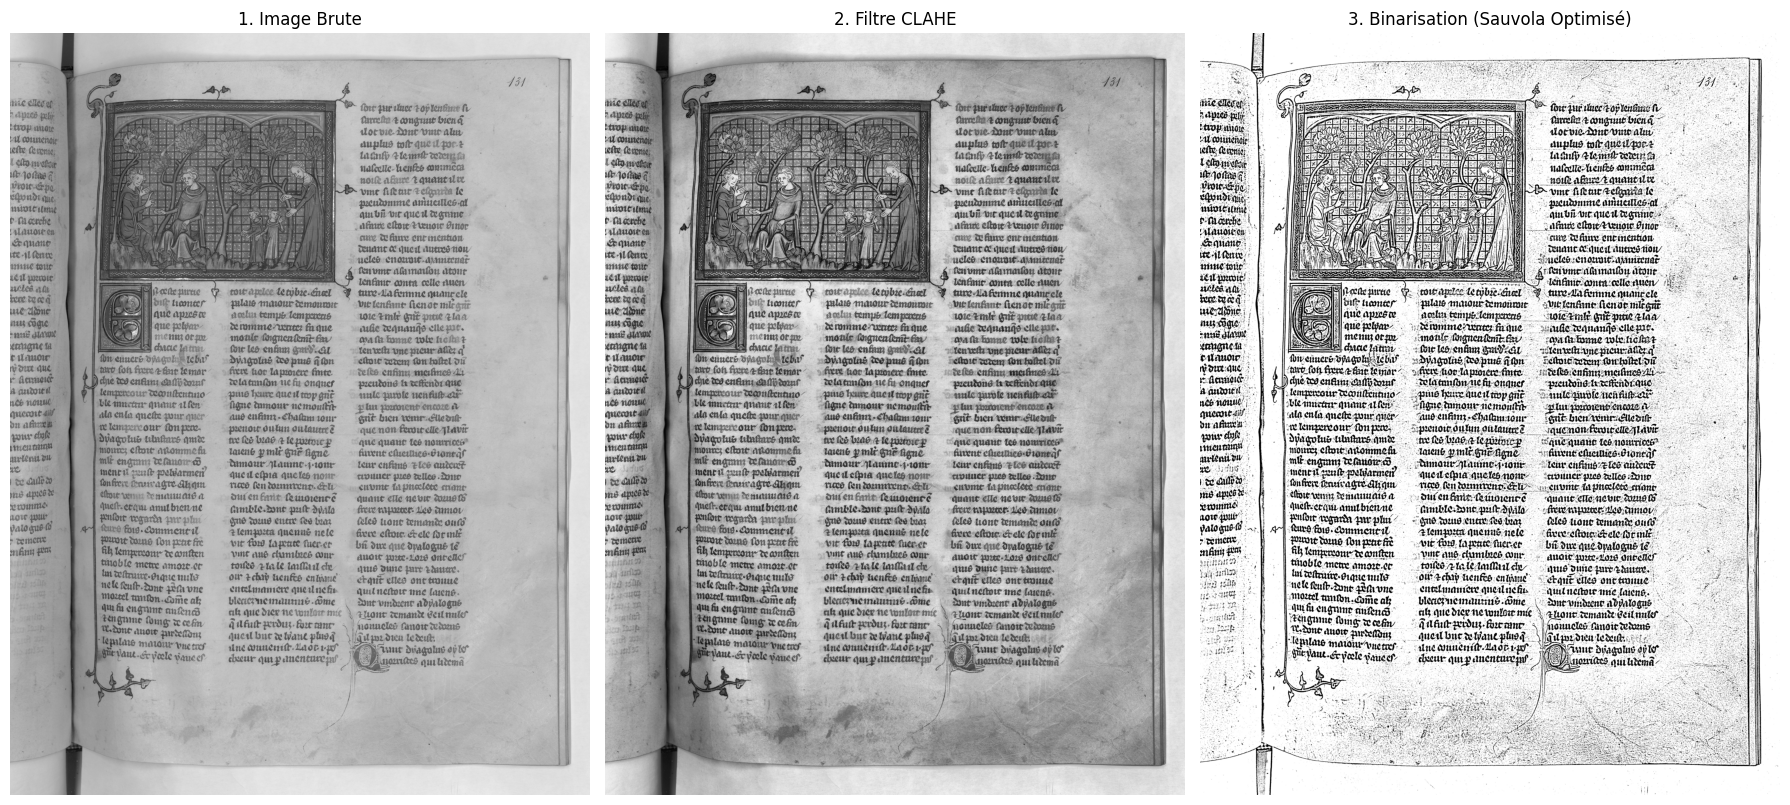

In [3]:
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np
from skimage.filters import threshold_sauvola

chemin_image_brute = "../dataset_nlp/raw_pages/page_cremma.jpg"
dossier_sortie = "../dataset_nlp/processed_pages"

image = cv2.imread(chemin_image_brute, cv2.IMREAD_GRAYSCALE)

if image is not None:
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    image_clahe = clahe.apply(image)
    
    # --- OPTIMISATION SAUVOLA ---
    window_size = 25
    # On ajoute le paramètre k (par défaut 0.2). En le baissant à 0.1 ou 0.05, 
    # l'algorithme est plus "tolérant" avec les gris clairs et les garde en noir.
    thresh_sauvola = threshold_sauvola(image_clahe, window_size=window_size, k=0.1) 
    
    image_binaire = (image_clahe > thresh_sauvola).astype(np.uint8) * 255
    
    cv2.imwrite(f"{dossier_sortie}/page_clahe.jpg", image_clahe)
    cv2.imwrite(f"{dossier_sortie}/page_binaire.jpg", image_binaire)

    fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('1. Image Brute')
    axes[0].axis('off')
    
    axes[1].imshow(image_clahe, cmap='gray')
    axes[1].set_title('2. Filtre CLAHE')
    axes[1].axis('off')
    
    axes[2].imshow(image_binaire, cmap='gray')
    axes[2].set_title('3. Binarisation (Sauvola Optimisé)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

In [4]:
import os

print("Démarrage de l'IA Kraken (BLLA) pour la segmentation...")

# Chemins
image_entree = "../dataset_nlp/processed_pages/page_clahe.jpg"
json_sortie = "../dataset_nlp/processed_pages/segmentation.json"

# On lance Kraken en mode segmentation de lignes de base (-bl)
!kraken -i {image_entree} {json_sortie} segment -bl

print(f"✅ Segmentation terminée ! Les coordonnées ont été sauvegardées dans : {json_sortie}")

Démarrage de l'IA Kraken (BLLA) pour la segmentation...
Segmenting ../dataset_nlp/processed_pages/page_clahe.jpg	You are using a CUDA device ('NVIDIA GeForce RTX 4060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
✓
✅ Segmentation terminée ! Les coordonnées ont été sauvegardées dans : ../dataset_nlp/processed_pages/segmentation.json


Kraken a détecté 159 lignes de texte !


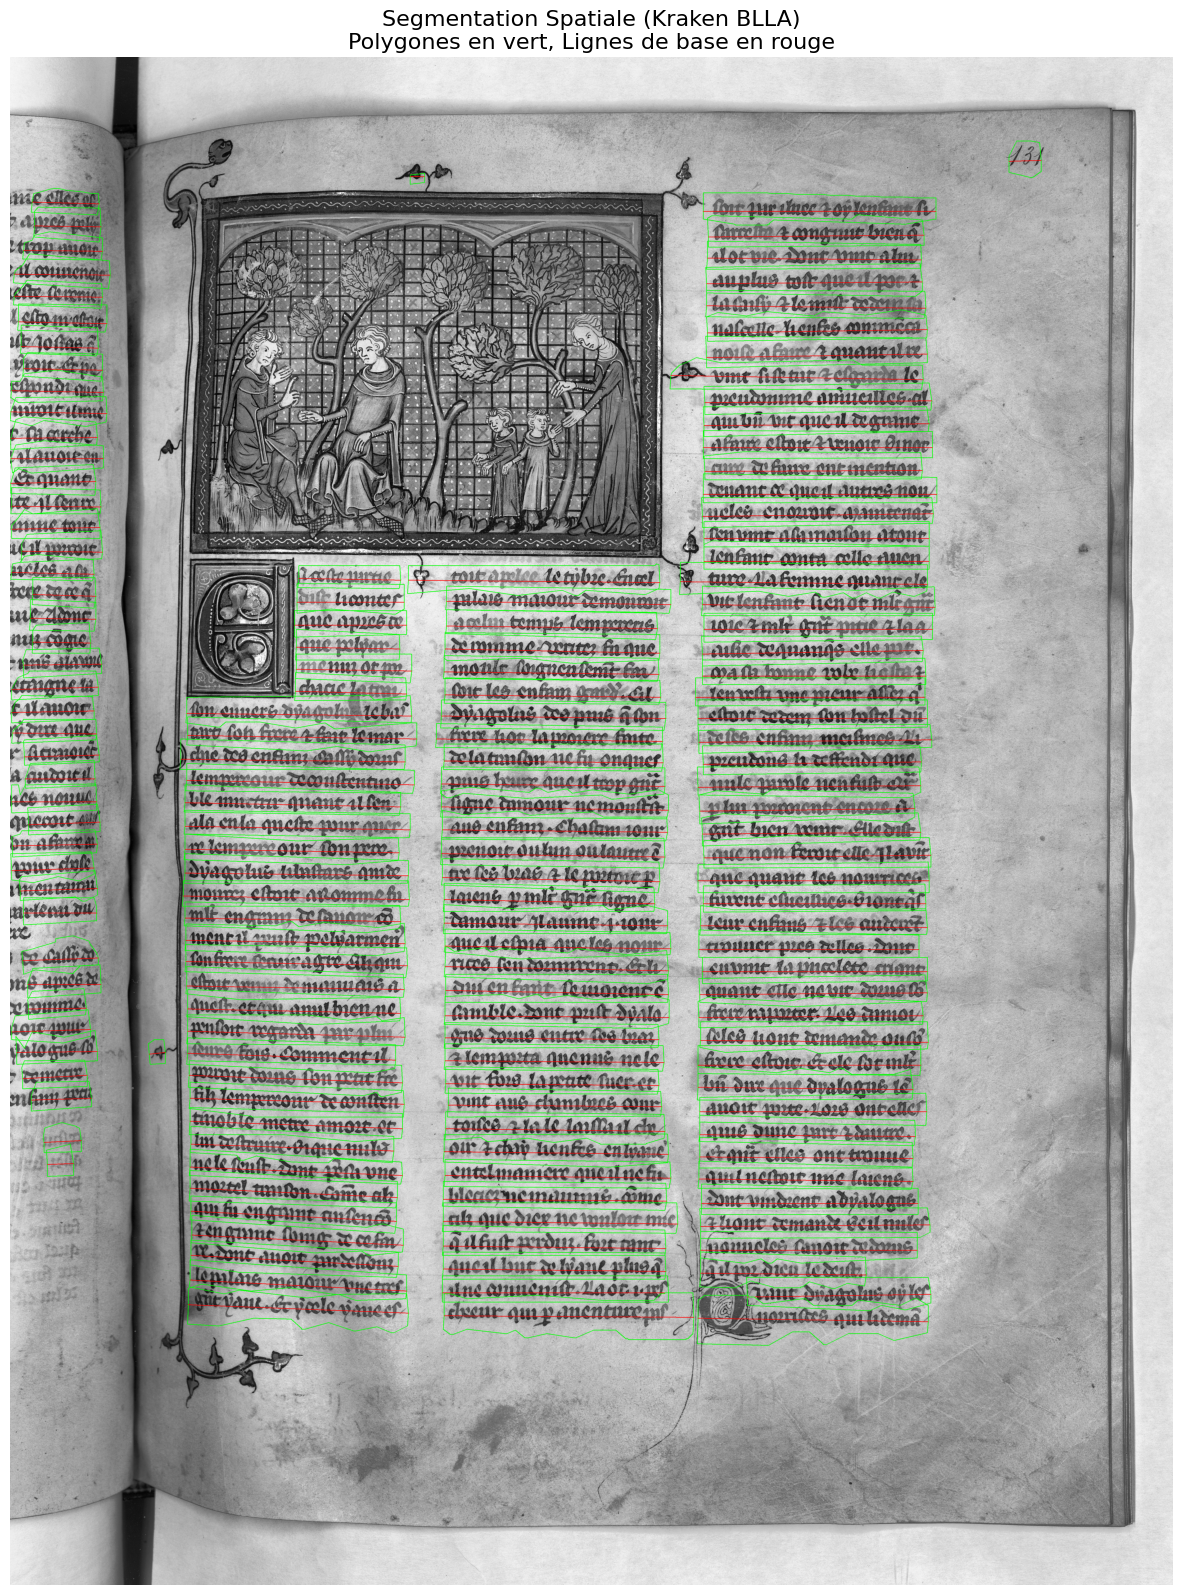

In [5]:
import json
import cv2
import matplotlib.pyplot as plt
import numpy as np

chemin_image = "../dataset_nlp/processed_pages/page_clahe.jpg"
chemin_json = "../dataset_nlp/processed_pages/segmentation.json"

# 1. Charger l'image avec OpenCV et la passer en couleurs pour afficher nos dessins
image = cv2.imread(chemin_image)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 2. Lire les coordonnées générées par Kraken
try:
    with open(chemin_json, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    print(f"Kraken a détecté {len(data['lines'])} lignes de texte !")

    # 3. Dessiner les polygones (zones de texte) et les baselines (lignes d'écriture)
    for line in data['lines']:
        # Le polygone complet autour du texte (en vert)
        polygon = np.array(line['boundary'], dtype=np.int32)
        polygon = polygon.reshape((-1, 1, 2))
        cv2.polylines(image, [polygon], isClosed=True, color=(0, 255, 0), thickness=2)
        
        # La baseline sur laquelle "repose" le texte (en rouge)
        baseline = np.array(line['baseline'], dtype=np.int32)
        baseline = baseline.reshape((-1, 1, 2))
        cv2.polylines(image, [baseline], isClosed=False, color=(255, 0, 0), thickness=2)

    # 4. Affichage grand format
    plt.figure(figsize=(15, 20))
    plt.imshow(image)
    plt.title("Segmentation Spatiale (Kraken BLLA)\nPolygones en vert, Lignes de base en rouge", fontsize=16)
    plt.axis('off')
    plt.show()

except FileNotFoundError:
    print("❌ Erreur : Le fichier JSON n'a pas été trouvé. La commande Kraken a-t-elle bien fonctionné ?")